In [7]:
import geopandas as gpd
import pickle
import matplotlib.pyplot as plt


In [8]:
roads = gpd.read_file("../data/gis/roads_final.geojson")

# project to meters (same CRS as graphs build)
roads = roads.to_crs(epsg=32643)

print("Roads loaded:", len(roads))


Roads loaded: 62143


In [9]:
with open("../data/graphs/pune_flooded_graph.gpickle", "rb") as f:
    G = pickle.load(f)

print("Graph loaded:", G.number_of_nodes())


Graph loaded: 62876


In [10]:
roads["failed"] = roads["road_id"].apply(
    lambda x: G.nodes[x]["failed"] if x in G else False
)

roads["failed"].value_counts()


failed
False    62111
True        32
Name: count, dtype: int64

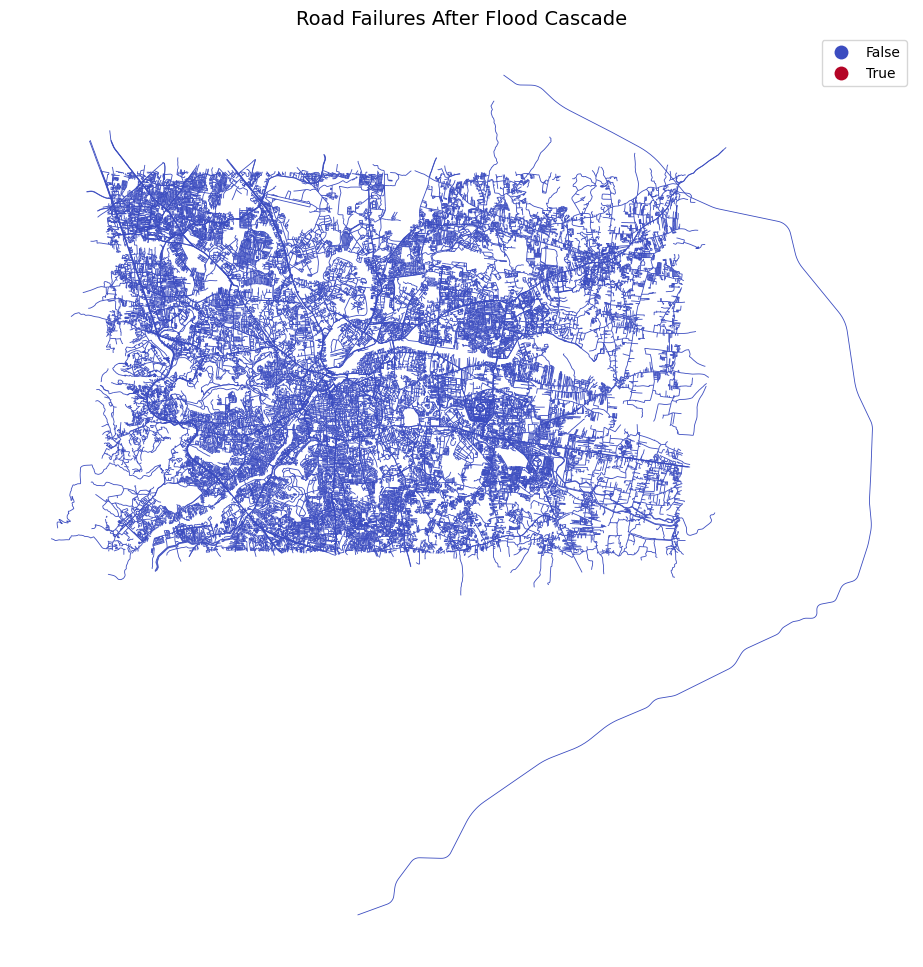

In [11]:
fig, ax = plt.subplots(figsize=(12, 12))

roads.plot(
    ax=ax,
    column="failed",
    categorical=True,
    legend=True,
    cmap="coolwarm",
    linewidth=0.6
)

ax.set_title("Road Failures After Flood Cascade", fontsize=14)
ax.axis("off")

plt.show()


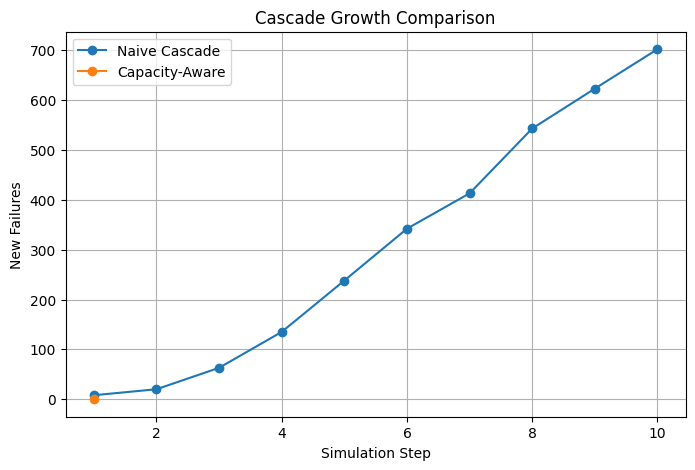

In [12]:
import json
import matplotlib.pyplot as plt

with open("../data/graphs/cascade_results.json", "r") as f:
    results = json.load(f)

naive = results["naive_cascade"]
capacity = results["capacity_cascade"]

plt.figure(figsize=(8,5))
plt.plot(range(1, len(naive)+1), naive, marker="o", label="Naive Cascade")
plt.plot(range(1, len(capacity)+1), capacity, marker="o", label="Capacity-Aware")

plt.xlabel("Simulation Step")
plt.ylabel("New Failures")
plt.title("Cascade Growth Comparison")
plt.legend()
plt.grid(True)
plt.show()
